<a href="https://colab.research.google.com/github/DarkSpartan345/Ciencia-de-datos-Energeticos/blob/main/DemandaEnergetica/Demanda%20Energetica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
!git clone https://github.com/DarkSpartan345/Ciencia-de-datos-Energeticos.git

fatal: destination path 'Ciencia-de-datos-Energeticos' already exists and is not an empty directory.


In [89]:
%cd /content/Ciencia-de-datos-Energeticos
!git pull

/content/Ciencia-de-datos-Energeticos
Already up to date.


In [70]:
import pandas as pd
import os
def Carga_datos(archivos,skiprow):
  # Carpeta donde están los archivos
  # Lista para almacenar DataFrames
  dataframes = []

  for archivo in archivos:

      try:
          # Leer el archivo (omitiendo las dos primeras filas)
          df = pd.read_excel(archivo, skiprows=skiprow)

          # Guardar en la lista
          dataframes.append(df)

      except FileNotFoundError:
          try:
              # Si no se encuentra el archivo .xlsx, intentar con .xls
              df = pd.read_excel(archivo.replace('.xlsx', '.xls'), skiprows=3)
              dataframes.append(df)
          except FileNotFoundError:
              print(f"Archivo no encontrado: {archivo}")
      except Exception as e:
          print(f"Error leyendo {archivo}: {e}")

  # Concatenar todos los DataFrames
  df_total = pd.concat(dataframes, ignore_index=True)

  return df_total


In [71]:
archivos=[f"/content/Ciencia-de-datos-Energeticos/DemandaEnergetica/Demanda_Energia/Demanda_Energia_SIN_{año}.xlsx" for año in range(2000,2026)]
df_total=Carga_datos(archivos,3)
DF = df_total.iloc[:, :2]
DF.columns = ['Fecha', 'Demanda Total (kWh)']
DF.head(1000)

,Fecha,Demanda Total (kWh)
0,2000-01-01,8.814187e+07
1,2000-01-02,8.912437e+07
2,2000-01-03,1.061863e+08
3,2000-01-04,1.095546e+08
4,2000-01-05,1.093482e+08
...,...,...
995,2002-09-22,1.101571e+08
996,2002-09-23,1.313407e+08
997,2002-09-24,1.312276e+08
998,2002-09-25,1.297427e+08


In [72]:
DF['Fecha'] = pd.to_datetime(DF['Fecha'], errors='coerce')
DF = DF.sort_values(by='Fecha')
df_mensual = DF.groupby(pd.Grouper(key='Fecha', freq='ME')).sum(numeric_only=True).reset_index()
df_mensual = df_mensual.iloc[:-1]
df_mensual.head(400)

,Fecha,Demanda Total (kWh)
0,2000-01-31,3.354237e+09
1,2000-02-29,3.278267e+09
2,2000-03-31,3.495203e+09
3,2000-04-30,3.298386e+09
4,2000-05-31,3.502127e+09
...,...,...
301,2025-02-28,6.392576e+09
302,2025-03-31,7.051482e+09
303,2025-04-30,6.762015e+09
304,2025-05-31,7.099986e+09


In [73]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_demanda_energetica(df, fecha_col='Fecha', demanda_col='Demanda Total (MWh)', titulo='Demanda energética total - Semestre'):
    """
    Grafica la demanda energética total a lo largo del tiempo.

    Parámetros:
    - df: DataFrame con al menos una columna de fechas y otra con la demanda total
    - fecha_col: nombre de la columna que contiene las fechas
    - demanda_col: nombre de la columna con la demanda total
    - titulo: título del gráfico

    Retorna:
    - None (muestra el gráfico)
    """
    # Asegurar formato datetime para la columna de fecha
    df[fecha_col] = pd.to_datetime(df[fecha_col], errors='coerce')

    # Ordenar por fecha
    df = df.sort_values(by=fecha_col)

    # Crear figura
    plt.figure(figsize=(12, 6))
    plt.plot(df[fecha_col], df[demanda_col], marker='o', linestyle='-', color='steelblue')

    # Formato del gráfico
    plt.title(titulo)
    plt.xlabel('Fecha')
    plt.ylabel('Demanda Total (kWh)')
    plt.grid(True)
    plt.tight_layout()
    plt.xticks(rotation=45)

    # Mostrar gráfico
    plt.show()


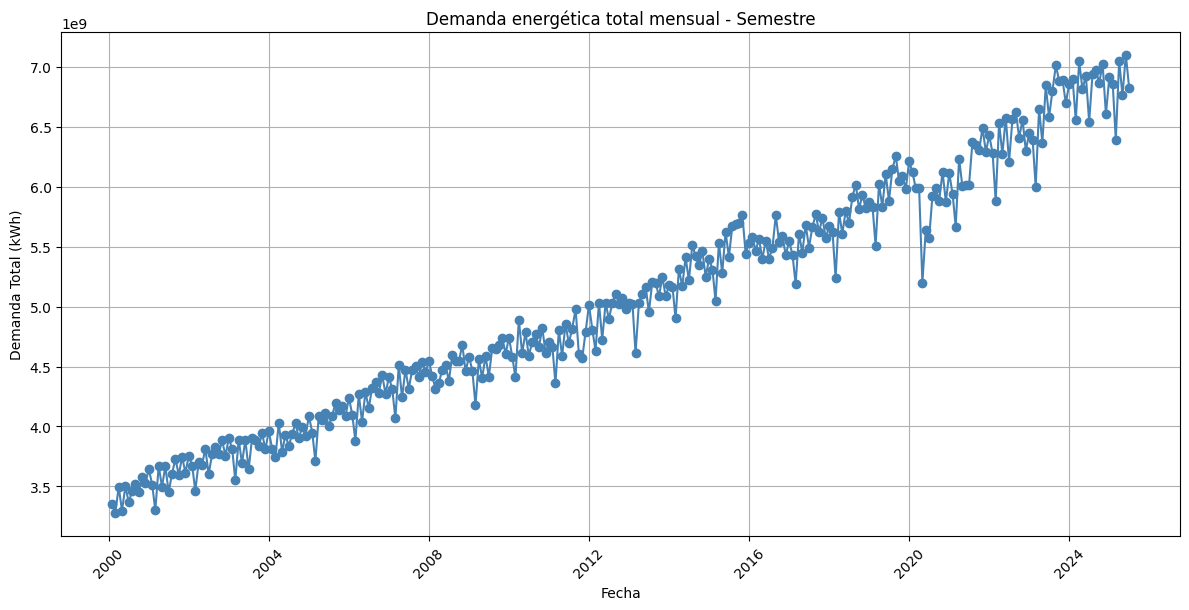

In [74]:
plot_demanda_energetica(df_mensual,titulo='Demanda energética total mensual - Semestre',demanda_col='Demanda Total (kWh)')

In [75]:
df_mensual.iloc[0]['Fecha']

Timestamp('2000-01-31 00:00:00')

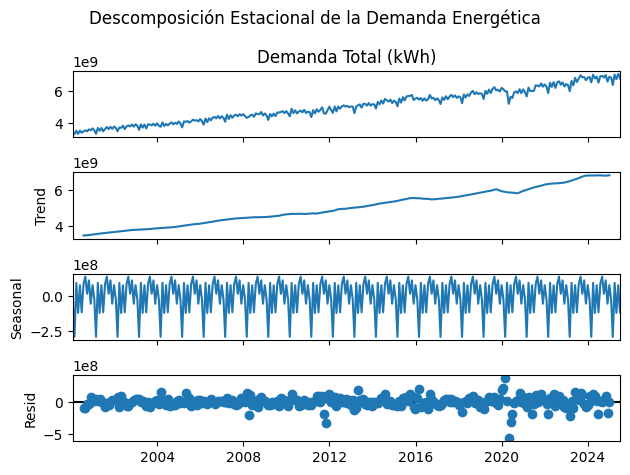

In [76]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Asegúrate de tener un índice tipo datetime y frecuencia definida
df_mensual['Fecha'] = pd.to_datetime(df_mensual[:]['Fecha'])
df_mensual.set_index('Fecha', inplace=True)
df = df_mensual.asfreq('ME')  # mensual

# Supongamos que la columna de interés es 'Demanda'
resultado = seasonal_decompose(df_mensual['Demanda Total (kWh)'], model='additive')

resultado.plot()
plt.suptitle('Descomposición Estacional de la Demanda Energética')
plt.tight_layout()
plt.show()


In [79]:

import numpy as np
# Extrae los componentes
trend = resultado.trend
seasonal = resultado.seasonal
residual = resultado.resid

# Elimina valores NaN para hacer los cálculos correctamente
valid_idx = (~trend.isna()) & (~seasonal.isna()) & (~residual.isna())
trend = trend[valid_idx]
seasonal = seasonal[valid_idx]
residual = residual[valid_idx]

# Calcular varianzas
var_resid = np.var(residual)
var_trend_resid = np.var(trend + residual)
var_season_resid = np.var(seasonal + residual)

# Fuerza de tendencia y estacionalidad
Ft = 1 - (var_resid / var_trend_resid)
Fs = 1 - (var_resid / var_season_resid)

print(f"Fuerza de la tendencia: {Ft:.3f}")
print(f"Fuerza de la estacionalidad: {Fs:.3f}")

Fuerza de la tendencia: 0.993
Fuerza de la estacionalidad: 0.682


#DATOS DEL CARBON

In [ ]:
archivos=["/content/Ciencia-de-datos-Energeticos/DemandaEnergetica/Carbon_termico/Carbón Termico.xlsx","/content/Ciencia-de-datos-Energeticos/DemandaEnergetica/Carbon_termico/Carbón Termico (2).xlsx"]
df_total_Carbon=Carga_datos(archivos,1)
df_total_Carbon.rename(columns={'Unnamed: 0': 'Fecha_Fin',
                                'Unnamed: 1': 'Fecha_Inicio',
                                'Unnamed: 2': 'Cantidad',
                                'Unnamed: 3': 'TON',
                                'Unnamed: 4': 'Lugar'}, inplace=True)
df_total_Carbon['Fecha_Fin'] = df_total_Carbon['Fecha_Fin'].astype(str)
df_total_Carbon.head(100)

In [ ]:
columnas_trimestre = df_total_Carbon.iloc[:, 5:]
columnas_trimestre.head(100)

In [ ]:
promedio_columnas=columnas_trimestre.mean().to_frame().T
promedio_columnas.head(100)

In [ ]:
import matplotlib.pyplot as plt

# Asegúrate de extraer los datos correctamente
x_labels = promedio_columnas.columns  # etiquetas: '1994 T4', '1995 T4', ...
y_values = promedio_columnas.iloc[0].values  # valores de la fila 0

# Crear el gráfico
plt.figure(figsize=(15, 5))
plt.plot(x_labels, y_values, marker='o', linestyle='-')
plt.xticks(rotation=90)  # rotar para que se vean mejor
plt.xlabel('Trimestre')
plt.ylabel('Promedio')
plt.title('Promedio por Trimestre')
plt.grid(True)
plt.tight_layout()
plt.show()


In [81]:
y_values.max().round()

np.float64(1333665.0)

#Datos Diesel

In [93]:
archivo=["/content/Ciencia-de-datos-Energeticos/DemandaEnergetica/Precios_Diesel/Precios.xlsx"]
df_total_Diesel=Carga_datos(archivo,6)
df_total_Diesel.head(20)

/usr/local/lib/python3.11/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,AÑO,MES,DEPARTAMENTO,MUNICIPIO,PRODUCTO,PRECIO_PROMEDIO_($),VOLUMEN_COMPRADO_(galones)
0,2021,ENERO,ANTIOQUIA,EL CARMEN DE VIBORAL,GASOLINA MOTOR EXTRA,11573.0,13515.0
1,2021,ENERO,ANTIOQUIA,EL SANTUARIO,GASOLINA MOTOR CORRIENTE,8410.0,135593.0
2,2021,ENERO,ANTIOQUIA,ENTRERRIOS,BIODIESEL CON MEZCLA,8579.0,69610.0
3,2021,ENERO,ANTIOQUIA,ENTRERRIOS,GASOLINA MOTOR CORRIENTE,8446.0,49380.0
4,2021,ENERO,ANTIOQUIA,ENVIGADO,GASOLINA MOTOR EXTRA,11969.0,102957.0
5,2021,ENERO,ANTIOQUIA,FREDONIA,GASOLINA MOTOR CORRIENTE,8824.0,38810.0
6,2021,ENERO,ANTIOQUIA,GIRARDOTA,BIODIESEL CON MEZCLA,8285.0,795892.0
7,2021,ENERO,ANTIOQUIA,GIRARDOTA,GASOLINA MOTOR CORRIENTE,8349.0,224271.0
8,2021,ENERO,ANTIOQUIA,GRANADA,GASOLINA MOTOR CORRIENTE,8875.0,11245.0
9,2021,ENERO,ANTIOQUIA,GUADALUPE,BIODIESEL CON MEZCLA,8878.0,33884.0


In [ ]:
# Si la columna se llama, por ejemplo, 'Combustible':
df_biodiesel = df_total_Diesel[df_total_Diesel['PRODUCTO'] == 'BIODIESEL CON MEZCLA']
df_biodiesel.head(100)